In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
train = pd.read_csv(r"C:\Users\tejas\Desktop\Capstone_P2\customer_churn_dataset-training-master.csv")
test = pd.read_csv(r"C:\Users\tejas\Desktop\Capstone_P2\customer_churn_dataset-testing-master.csv")

print(train.shape)
print(test.shape)

(440833, 12)
(64374, 12)


In [5]:
train.head()
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
train["Churn"].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [7]:
train.fillna(train.median(numeric_only=True), inplace=True)
test.fillna(test.median(numeric_only=True), inplace=True)

In [8]:
train = train.drop("CustomerID", axis=1)
test = test.drop("CustomerID", axis=1)

In [9]:
categorical_cols = ["Gender", "Subscription Type", "Contract Length"]

train = pd.get_dummies(train, columns=categorical_cols, drop_first=True)
test = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

In [10]:
print(train.columns)

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction', 'Churn', 'Gender_Male',
       'Subscription Type_Premium', 'Subscription Type_Standard',
       'Contract Length_Monthly', 'Contract Length_Quarterly'],
      dtype='object')


In [11]:
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [12]:
X_train = train.drop("Churn", axis=1)
y_train = train["Churn"]

X_test = test.drop("Churn", axis=1)
y_test = test["Churn"]

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC AUC:", roc_auc_score(y_test, xgb_probs))

XGBoost ROC AUC: 0.7077888633954279


In [15]:
from sklearn.metrics import classification_report

pred = xgb.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374



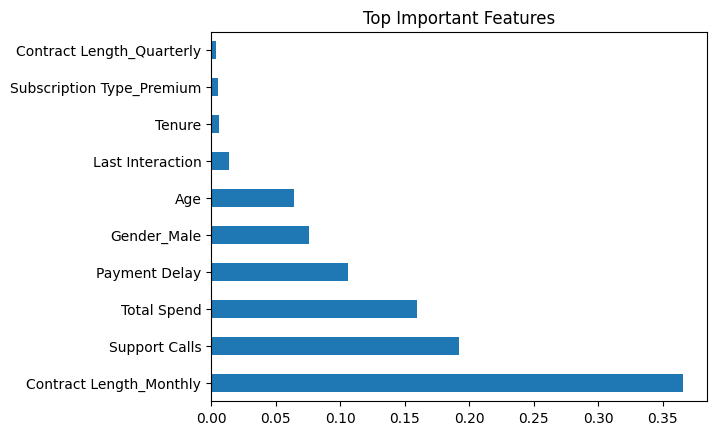

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

importance = xgb.feature_importances_

features = pd.Series(importance, index=X_train.columns)

features.nlargest(10).plot(kind="barh")

plt.title("Top Important Features")
plt.show()

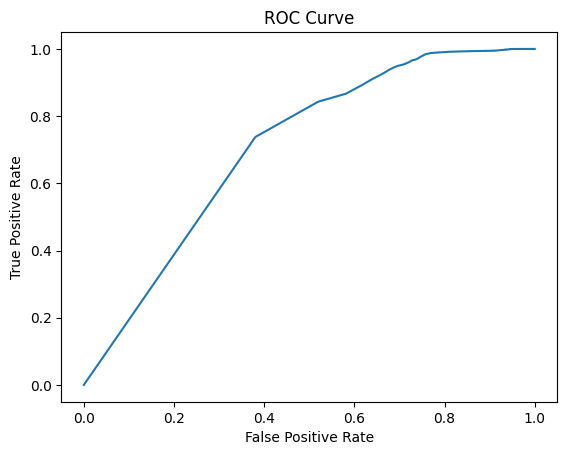

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, xgb_probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [18]:
import joblib

joblib.dump(X_train.columns, "model_columns.pkl")

['model_columns.pkl']